#  Bakken Basin Exploratory Data Analysis

**Project:** First-Year Oil Production Prediction  
**Target Variable:** cumulative oil production (cum_oil_12mo) in the first 12 months (BBL)  
**Dataset:** Bakken Basin monthly production records

This notebook covers:
1. Dataset overview & schema
2. Target variable distribution
3. Feature distributions & outlier detection
4. Correlation analysis
5. Production decline curves
6. Geographic & geological patterns
7. Completion design analysis (proppant, fluid, lateral length)
8. Key findings & modeling implications


## 1. Setup & Data Loading

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Plot styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("Libraries loaded ")


Libraries loaded 


In [158]:
# Load raw monthly production file ──
# Update this path to point to your actual file
RAW_PATH = "../data/Bakken Basin Well Monthly Production.CSV"

df_raw = pd.read_csv(RAW_PATH, low_memory=False, parse_dates=["Monthly Production Date"])

print(f"Raw shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Unique wells (API/UWI): {df_raw['API/UWI'].nunique():,}")
print(f"Date range : {df_raw['Monthly Production Date'].min().date()} → "
      f"{df_raw['Monthly Production Date'].max().date()}")
df_raw.head(3)


Raw shape : 4,243,618 rows × 36 columns
Unique wells (API/UWI): 29,598
Date range : 1951-04-01 → 2025-08-01


,API/UWI,Monthly Production Date,Monthly Oil,Monthly Gas,Monthly Water,Monthly BOE,Days,Cum Oil,Cum Gas,Cum Water,...,Producing Month Number,Monthly Oil Per perforated Ft,Monthly Gas Per perforated Ft,Monthly BOE Per perforated Ft,Daily Avg Oil Per perforated Ft,Daily Avg Gas Per perforated Ft,Daily Avg BOE Per perforated Ft,Cum Oil Per perforated Ft,Cum Gas Per perforated Ft,Cum BOE Per perforated Ft
0,25019210410000,1981-01-01,42.0,93.0,1321.0,57.5,NaN,42.0,93.0,1321.0,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25019210410000,1981-02-01,245.0,69.0,2128.0,256.5,NaN,287.0,162.0,3449.0,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25019210410000,1981-03-01,175.0,93.0,1622.0,190.5,NaN,462.0,255.0,5071.0,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Schema Overview & Missing Values

In [159]:
# Data types and null counts
info = pd.DataFrame({
    "dtype"   : df_raw.dtypes,
    "non_null": df_raw.notna().sum(),
    "null_pct": (df_raw.isna().mean() * 100).round(1),
}).sort_values("null_pct", ascending=False)

print(info.to_string())


                                          dtype  non_null  null_pct
DI Landing Zone                          object   1558442      63.3
Total Fluid                             float64   1568187      63.0
Total Proppant                          float64   2159218      49.1
Cum BOE Per perforated Ft               float64   2507472      40.9
Monthly Oil Per perforated Ft           float64   2507472      40.9
Monthly Gas Per perforated Ft           float64   2507472      40.9
Monthly BOE Per perforated Ft           float64   2507472      40.9
Daily Avg Oil Per perforated Ft         float64   2507472      40.9
Daily Avg Gas Per perforated Ft         float64   2507472      40.9
Daily Avg BOE Per perforated Ft         float64   2507472      40.9
Cum Oil Per perforated Ft               float64   2507472      40.9
Cum Gas Per perforated Ft               float64   2507472      40.9
DI Lateral Length                       float64   2507472      40.9
Gross Perforated Interval               float64 

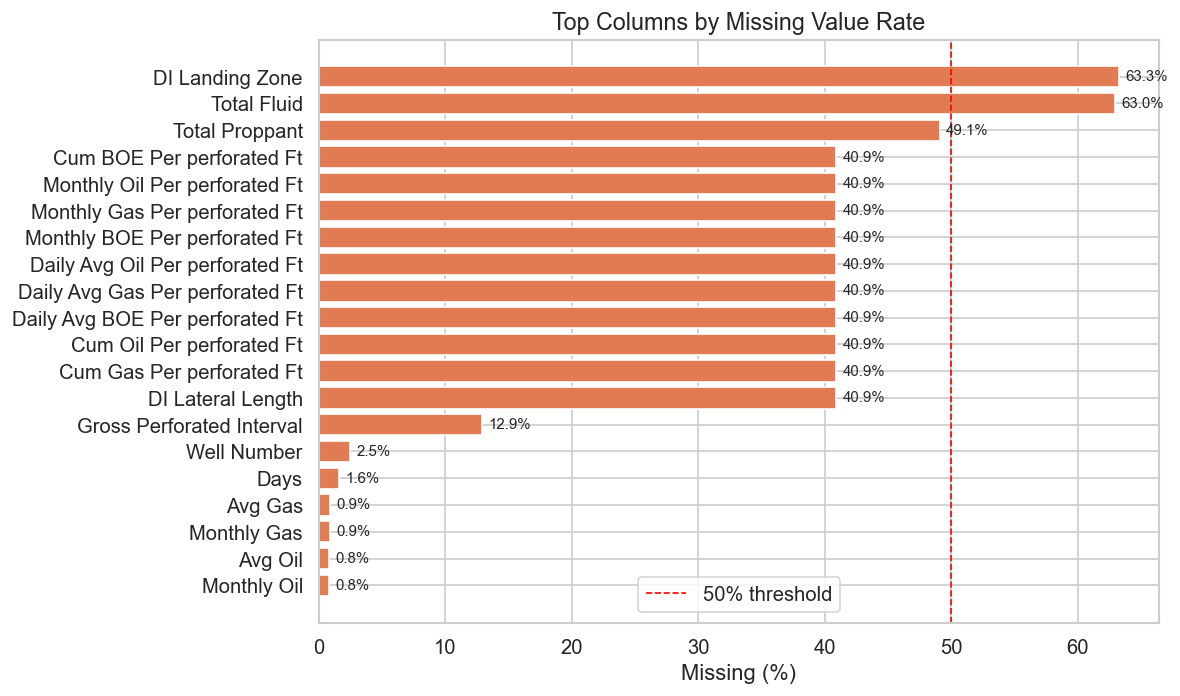


 Columns above 50% missing will be imputed with 'UNKNOWN'.


In [160]:
# Missingness heatmap (top 20 columns by null %)
top_missing = info[info["null_pct"] > 0].head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_missing.index[::-1], top_missing["null_pct"][::-1], color="#e07b54")
ax.set_xlabel("Missing (%)")
ax.set_title("Top Columns by Missing Value Rate")
ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax.legend()
for bar, val in zip(bars, top_missing["null_pct"][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()
print("\n Columns above 50% missing will be imputed with 'UNKNOWN'.")


Many of the missing columns are derived features. For example:Monthly Oil Per perforated Ft, Monthly Gas Per perforated Ft,
Monthly BOE Per perforated Ft, Daily Avg Oil Per perforated Ft, Daily Avg Gas Per perforated Ft, Daily Avg BOE Per perforated Ft, Cum Oil Per perforated Ft, Cum Gas Per perforated Ft, Cum BOE Per perforated Ft; all depend on "Gross Perforated Interval"

Missingness Interpretation:

- Completion-related variables such as DI Landing Zone, Total Fluid,
  Total Proppant, DI Lateral Length, and Gross Perforated Interval
  contain missing values.

- These columns will not be dropped  because they are
  important engineering variables for production prediction.

- Categorical missing values such as DI Landing Zone will be filled with
  'UNKNOWN'.

- Numeric completion variables will be imputed using median-based methods.

- Derived per-foot production columns will be reviewed separately because
  their missingness may be caused by missing perforated interval data.


In [161]:
#Duplicate Check
duplicate_rows = df_raw.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_rows / len(df_raw) * 100:.2f}%")

Number of duplicate rows: 0
Duplicate percentage: 0.00%


In [162]:
#Numerical Summary
numeric_cols = df_raw.select_dtypes(include=["int64", "float64"]).columns

display(df_raw[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
API/UWI,4243618.0,3.111935e+13,3.783259e+12,2.501921e+13,2.509122e+13,3.305301e+13,3.306102e+13,4.006321e+13
Monthly Oil,4211190.0,1.801765e+03,3.912068e+03,-4.020000e+02,3.090000e+02,7.760000e+02,1.783000e+03,3.211410e+05
Monthly Gas,4204746.0,3.366553e+03,8.196519e+03,-5.500000e+01,2.190000e+02,9.740000e+02,3.041000e+03,8.124110e+05
Monthly Water,4213828.0,2.822183e+03,9.585005e+03,-5.150000e+02,2.220000e+02,9.680000e+02,2.631000e+03,6.290961e+06
Monthly BOE,4243618.0,2.343949e+03,4.788709e+03,-4.020000e+02,3.890000e+02,9.935000e+02,2.370500e+03,3.248898e+05
Days,4177484.0,2.729672e+01,6.832289e+00,0.000000e+00,2.800000e+01,3.000000e+01,3.100000e+01,3.100000e+01
Cum Oil,4216153.0,2.112486e+05,4.972066e+05,0.000000e+00,7.095600e+04,1.555890e+05,2.654110e+05,2.820465e+07
Cum Gas,4219054.0,2.962476e+05,8.334574e+05,0.000000e+00,4.882000e+04,1.513855e+05,3.337140e+05,5.830131e+07
Cum Water,4224548.0,3.137374e+05,1.313663e+06,0.000000e+00,3.035400e+04,1.169020e+05,2.754932e+05,7.954671e+07
Avg Oil,4211190.0,6.817719e+01,1.572357e+02,-4.020000e+02,1.190000e+01,2.832000e+01,6.607000e+01,4.986600e+04


In [163]:
#check for Negative Production Values
negative_cols = [
    "Monthly Oil",
    "Monthly Gas",
    "Monthly Water",
    "Monthly BOE"
]

for col in negative_cols:
    count = (df_raw[col] < 0).sum()
    pct = count / len(df_raw) * 100

    print(
        f"{col}: {count:,} records "
        f"({pct:.4f}%)"
    )

Monthly Oil: 227 records (0.0053%)
Monthly Gas: 4 records (0.0001%)
Monthly Water: 72 records (0.0017%)
Monthly BOE: 207 records (0.0049%)


#### With a dataset of 4.24 million records, these negatives are essentially negligible and will be removed

In [164]:
#Remove the negative production data
production_cols = [
    "Monthly Oil",
    "Monthly Gas",
    "Monthly Water",
    "Monthly BOE"
]

for col in production_cols:
    df_raw = df_raw[df_raw[col] >= 0]

print(f"Remaining records: {len(df_raw):,}")

Remaining records: 4,170,184


In [165]:
#check for Zero production months when cummulative is not zero
df_raw[df_raw["Days"] == 0].head()

,API/UWI,Monthly Production Date,Monthly Oil,Monthly Gas,Monthly Water,Monthly BOE,Days,Cum Oil,Cum Gas,Cum Water,...,Producing Month Number,Monthly Oil Per perforated Ft,Monthly Gas Per perforated Ft,Monthly BOE Per perforated Ft,Daily Avg Oil Per perforated Ft,Daily Avg Gas Per perforated Ft,Daily Avg BOE Per perforated Ft,Cum Oil Per perforated Ft,Cum Gas Per perforated Ft,Cum BOE Per perforated Ft
12,25019210970000,1993-11-01,1333.0,667.0,7133.0,1444.17,0.0,2739.0,1370.0,10871.0,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,25019210970000,1994-01-01,563.0,281.0,4473.0,609.83,0.0,4470.0,2235.0,23225.0,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,25019210970000,1994-07-01,558.0,279.0,7898.0,604.50,0.0,5921.0,2960.0,41310.0,...,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,25019210970000,1994-08-01,390.0,195.0,7637.0,422.50,0.0,6311.0,3155.0,48947.0,...,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1061,25021052300000,1988-09-01,768.0,0.0,480.0,768.00,0.0,237644.0,10945.0,73380.0,...,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [166]:
days_zero = (df_raw["Days"] == 0).sum()

print(f"Days = 0 records: {days_zero:,}")
print(f"Percentage of dataset: {100*days_zero/len(df_raw):.4f}%")


Days = 0 records: 8,661
Percentage of dataset: 0.2077%


In [167]:
print("Days = 0 :", (df_raw["Days"] == 0).sum())
print("Days is null :", df_raw["Days"].isna().sum())
print("Total removed :", (df_raw["Days"] <= 0).sum() + df_raw["Days"].isna().sum())

Days = 0 : 8661
Days is null : 45769
Total removed : 54430


In [168]:
# Records before cleaning
rows_before = len(df_raw)

# Remove invalid producing-day records
df_raw = df_raw[df_raw["Days"] > 0].copy()

rows_after = len(df_raw)

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Rows removed         : {rows_before - rows_after:,}")
print(f"Percent removed      : {(rows_before - rows_after)/rows_before*100:.4f}%")

Rows before cleaning : 4,170,184
Rows after cleaning  : 4,115,754
Rows removed         : 54,430
Percent removed      : 1.3052%


Records with missing or non-positive producing days were removed because producing days are required for daily-rate calculations and operational feature engineering. This process removed 1.31% of observations and retained over 4.1 million production records for analysis.

In [169]:
#Categorical Summary

categorical_cols = df_raw.select_dtypes(include=["object"]).columns

cat_summary = pd.DataFrame({
    "unique_values": df_raw[categorical_cols].nunique(),
    "missing_pct": df_raw[categorical_cols].isna().mean() * 100
}).sort_values("unique_values", ascending=False)

display(cat_summary)

,unique_values,missing_pct
Well Number,17571,1.512457
Well Name,13366,0.000000
Operator Company Name,554,0.000000
Reservoir,63,0.022693
Production Type,12,0.000000
Well Status,8,0.000000
DI Landing Zone,4,62.187706
Entity Type,2,0.000000


#### Reservoir is one of the strongest geological predictors in your dataset

In [170]:

df_raw["Reservoir"].value_counts().head(15)

Reservoir
MIDDLE BAKKEN (BAKKEN POOL)    1171916
MADISON POOL                    650700
THREE FORKS (BAKKEN POOL)       619212
MULTIPLE                        564676
BAKKEN                          225294
EAGLE                           213212
SILURO-ORDOVICIAN               166456
BAKKEN POOL                     102067
RED RIVER                        78273
RATCLIFFE                        43596
MADISON                          29808
RED RIVER FORMATION              26452
UPPER BAKKEN (BAKKEN POOL)       23579
HEATH                            18543
DEVONIAN                         18064
Name: count, dtype: int64

In [171]:
df_raw["DI Landing Zone"] = (
    df_raw["DI Landing Zone"]
    .fillna("UNKNOWN")
)

df_raw["DI Landing Zone"].value_counts(dropna=False)

DI Landing Zone
UNKNOWN               2559493
Bakken Middle          870087
Three Forks Middle     303899
Three Forks Upper      301564
Three Forks Lower       80711
Name: count, dtype: int64

### Summary
A quality-control review identified a very small number of negative production values. Negative values represented less than 0.01% of the dataset for all production variables (oil, gas, water, and BOE). Since production volumes cannot be physically negative and these records likely represent accounting adjustments or reporting corrections, they were removed prior to modeling. The impact on dataset size was negligible while improving data consistency and model reliability.

The Days variable was assessed for validity and completeness. A total of 8,661 records reported zero producing days despite having production volumes, while additional records contained missing values for producing days. Because this variable is required for calculating daily production metrics and represents an important operational feature, records with missing or non-positive values were removed. In total, 54,430 observations (1.31% of the dataset) were excluded, leaving 4.12 million high-quality records for analysis and modeling.

Production records are concentrated within a small number of reservoirs, with Middle Bakken, Madison Pool, and Three Forks accounting for the majority of observations. This suggests that reservoir type is likely to be a significant predictor of production performance and should be retained as a key modeling feature.

Reservoir type exhibits a strong relationship with oil production. Wells completed in Bakken Pool and Three Forks formations generally demonstrate higher median monthly oil production and wider production distributions than wells in other reservoirs. This suggests that reservoir characteristics are a major driver of production variability and confirms the importance of including reservoir information as a predictive feature in the machine learning model.

## 3. Target Variable- `cum_oil_12mo`

We build the target by summing `Monthly Oil` for `Producing Month Number` 1–12 per well.

In [172]:
#  Build target from raw monthly data
# Filter to oil-producing wells
oil_types = {"OIL", "O&G", "OIL & GAS"}
df_oil = df_raw[df_raw["Production Type"].str.strip().str.upper().isin(oil_types)].copy()

# Keep months 1-12 only
df_12 = df_oil[
    df_oil["Producing Month Number"].between(1, 12)
].copy()

# Sum per well
target = (
    df_12.groupby("API/UWI")["Monthly Oil"]
    .sum()
    .rename("cum_oil_12mo")
    .reset_index()
)

# Only keep wells that have all 12 months
month_counts = df_12.groupby("API/UWI")["Producing Month Number"].count()
full_wells = month_counts[month_counts >= 12].index
target = target[target["API/UWI"].isin(full_wells)]

print(f"Wells with complete 12-month production: {len(target):,}")
print(f"\ncum_oil_12mo statistics (BBL):")
print(target["cum_oil_12mo"].describe().apply(lambda x: f"{x:,.0f}"))


Wells with complete 12-month production: 20,601

cum_oil_12mo statistics (BBL):
count     20,601
mean     100,247
std       75,297
min            0
25%       41,548
50%       83,002
75%      144,892
max      533,656
Name: cum_oil_12mo, dtype: object


First-year cumulative oil production was selected as the target variable for the machine learning model. The target was calculated by aggregating monthly oil production over the first twelve producing months for wells with complete production histories. A total of 20,601 wells satisfied this criterion.

First-year cumulative oil production exhibits substantial positive skewness, with a relatively small number of high-performing wells generating disproportionately large production volumes. This indicates that the target variable is not normally distributed and may benefit from transformation prior to modeling.

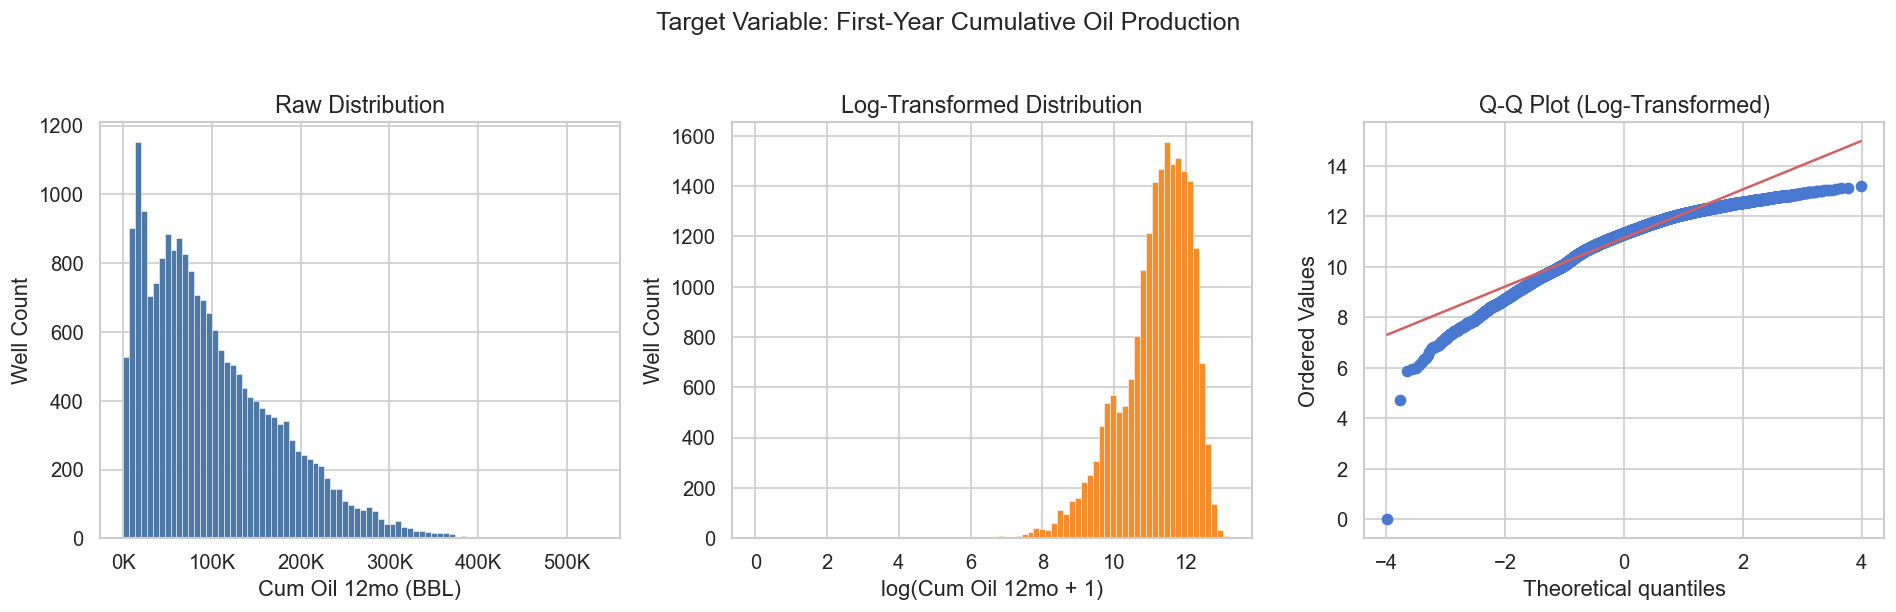

Raw skewness  : 1.01  → highly skewed — log-transform recommended
Log skewness  : -1.02  → still skewed

 Train models on log(cum_oil_12mo) for better residual behaviour.


In [173]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Raw distribution
axes[0].hist(target["cum_oil_12mo"], bins=80, color="#4e79a7", edgecolor="white", linewidth=0.3)
axes[0].set_title("Raw Distribution")
axes[0].set_xlabel("Cum Oil 12mo (BBL)")
axes[0].set_ylabel("Well Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# Log-transformed
log_vals = np.log1p(target["cum_oil_12mo"])
axes[1].hist(log_vals, bins=80, color="#f28e2b", edgecolor="white", linewidth=0.3)
axes[1].set_title("Log-Transformed Distribution")
axes[1].set_xlabel("log(Cum Oil 12mo + 1)")
axes[1].set_ylabel("Well Count")

# QQ plot vs normal
stats.probplot(log_vals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (Log-Transformed)")

plt.suptitle("Target Variable: First-Year Cumulative Oil Production", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

skew = target["cum_oil_12mo"].skew()
log_skew = log_vals.skew()
print(f"Raw skewness  : {skew:.2f}  → {'highly skewed — log-transform recommended' if abs(skew) > 1 else 'acceptable'}")
print(f"Log skewness  : {log_skew:.2f}  → {'near-normal ' if abs(log_skew) < 0.5 else 'still skewed'}")
print("\n Train models on log(cum_oil_12mo) for better residual behaviour.")


The distribution of first-year cumulative oil production is strongly right-skewed, indicating that while most wells produce relatively modest volumes during their first year, a small number of exceptionally productive wells generate substantially higher oil volumes. This is evident in the raw distribution, which exhibits a long upper tail extending beyond 500,000 barrels. Applying a logarithmic transformation significantly reduces this skewness, producing a more symmetric and approximately bell-shaped distribution. The Q-Q plot of the log-transformed target shows that the majority of observations align reasonably well with the theoretical normal distribution, although some deviations remain in the lower and upper tails due to very low- and very high-performing wells. Overall, the log transformation successfully stabilizes the variance, reduces the influence of extreme outliers, and creates a target variable that is more suitable for machine learning modeling. Consequently, subsequent models will be trained using the log-transformed first-year cumulative oil production target, with predictions converted back to original barrel units for interpretation and reporting.

In [174]:
# Outlier detection using IQR 
Q1 = target["cum_oil_12mo"].quantile(0.25)
Q3 = target["cum_oil_12mo"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = target[(target["cum_oil_12mo"] < lower) | (target["cum_oil_12mo"] > upper)]
print(f"IQR bounds   : [{lower:,.0f}, {upper:,.0f}] BBL")
print(f"Outliers     : {len(outliers):,} wells ({len(outliers)/len(target)*100:.1f}%)")
print(f"\nTop 10 highest-producing wells:")
print(target.nlargest(10, "cum_oil_12mo")[["API/UWI","cum_oil_12mo"]].to_string(index=False))


IQR bounds   : [-113,468, 299,908] BBL
Outliers     : 330 wells (1.6%)

Top 10 highest-producing wells:
       API/UWI  cum_oil_12mo
33053007060000      533656.0
33025012590000      496835.0
33053066680000      494078.0
33053093240000      483461.0
33053071830000      471200.0
33053070320000      465822.0
33053092650000      456228.0
33053096100000      454127.0
33053098880000      446984.0
33053077540000      443547.0


An interquartile range (IQR) analysis was performed to identify unusually high- or low-producing wells based on first-year cumulative oil production. Several wells were flagged as statistical outliers, primarily on the upper end of the distribution. These observations were not treated as data quality issues because they represent legitimate high-performing wells within the basin. Since exceptional well performance is an important aspect of production variability, all outlier wells were retained for modeling. The use of a logarithmic transformation on the target variable mitigates the influence of these extreme values while preserving valuable production information

First-year cumulative oil production was selected as the target variable for the machine learning model. The target was calculated by aggregating monthly oil production over the first twelve producing months for wells with complete production histories. A total of 20,601 wells satisfied this criterion. Exploratory analysis revealed a strongly right-skewed distribution, with a small number of exceptionally productive wells creating a long upper tail. Applying a natural logarithm transformation substantially reduced skewness and produced a distribution that more closely approximates normality. Consequently, all machine learning models will be trained using log-transformed first-year cumulative oil production as the target variable, with predictions converted back to original production units for interpretation.

## 4. Feature Distributions

In [175]:
#  Attach static features to target
static = (
    df_oil.sort_values("Producing Month Number")
    .groupby("API/UWI")
    .first()
    .reset_index()
)[["API/UWI", "Total Proppant", "Total Fluid", "Gross Perforated Interval",
   "DI Lateral Length", "Reservoir", "DI Landing Zone", "Production Type", "Well Status"]]

df_eda = target.merge(static, on="API/UWI", how="left")
print(f"EDA dataset: {df_eda.shape[0]:,} wells × {df_eda.shape[1]} columns")
df_eda.head(3)


EDA dataset: 20,601 wells × 10 columns


,API/UWI,cum_oil_12mo,Total Proppant,Total Fluid,Gross Perforated Interval,DI Lateral Length,Reservoir,DI Landing Zone,Production Type,Well Status
0,25019210750000,15372.0,NaN,NaN,NaN,1455.0,MULTIPLE,UNKNOWN,OIL,ABANDONED
1,25019210840000,127327.0,NaN,NaN,358.0,NaN,MADISON,UNKNOWN,OIL,P & A
2,25019210960000,53173.0,NaN,NaN,11.0,NaN,MULTIPLE,UNKNOWN,OIL,SHUT-IN


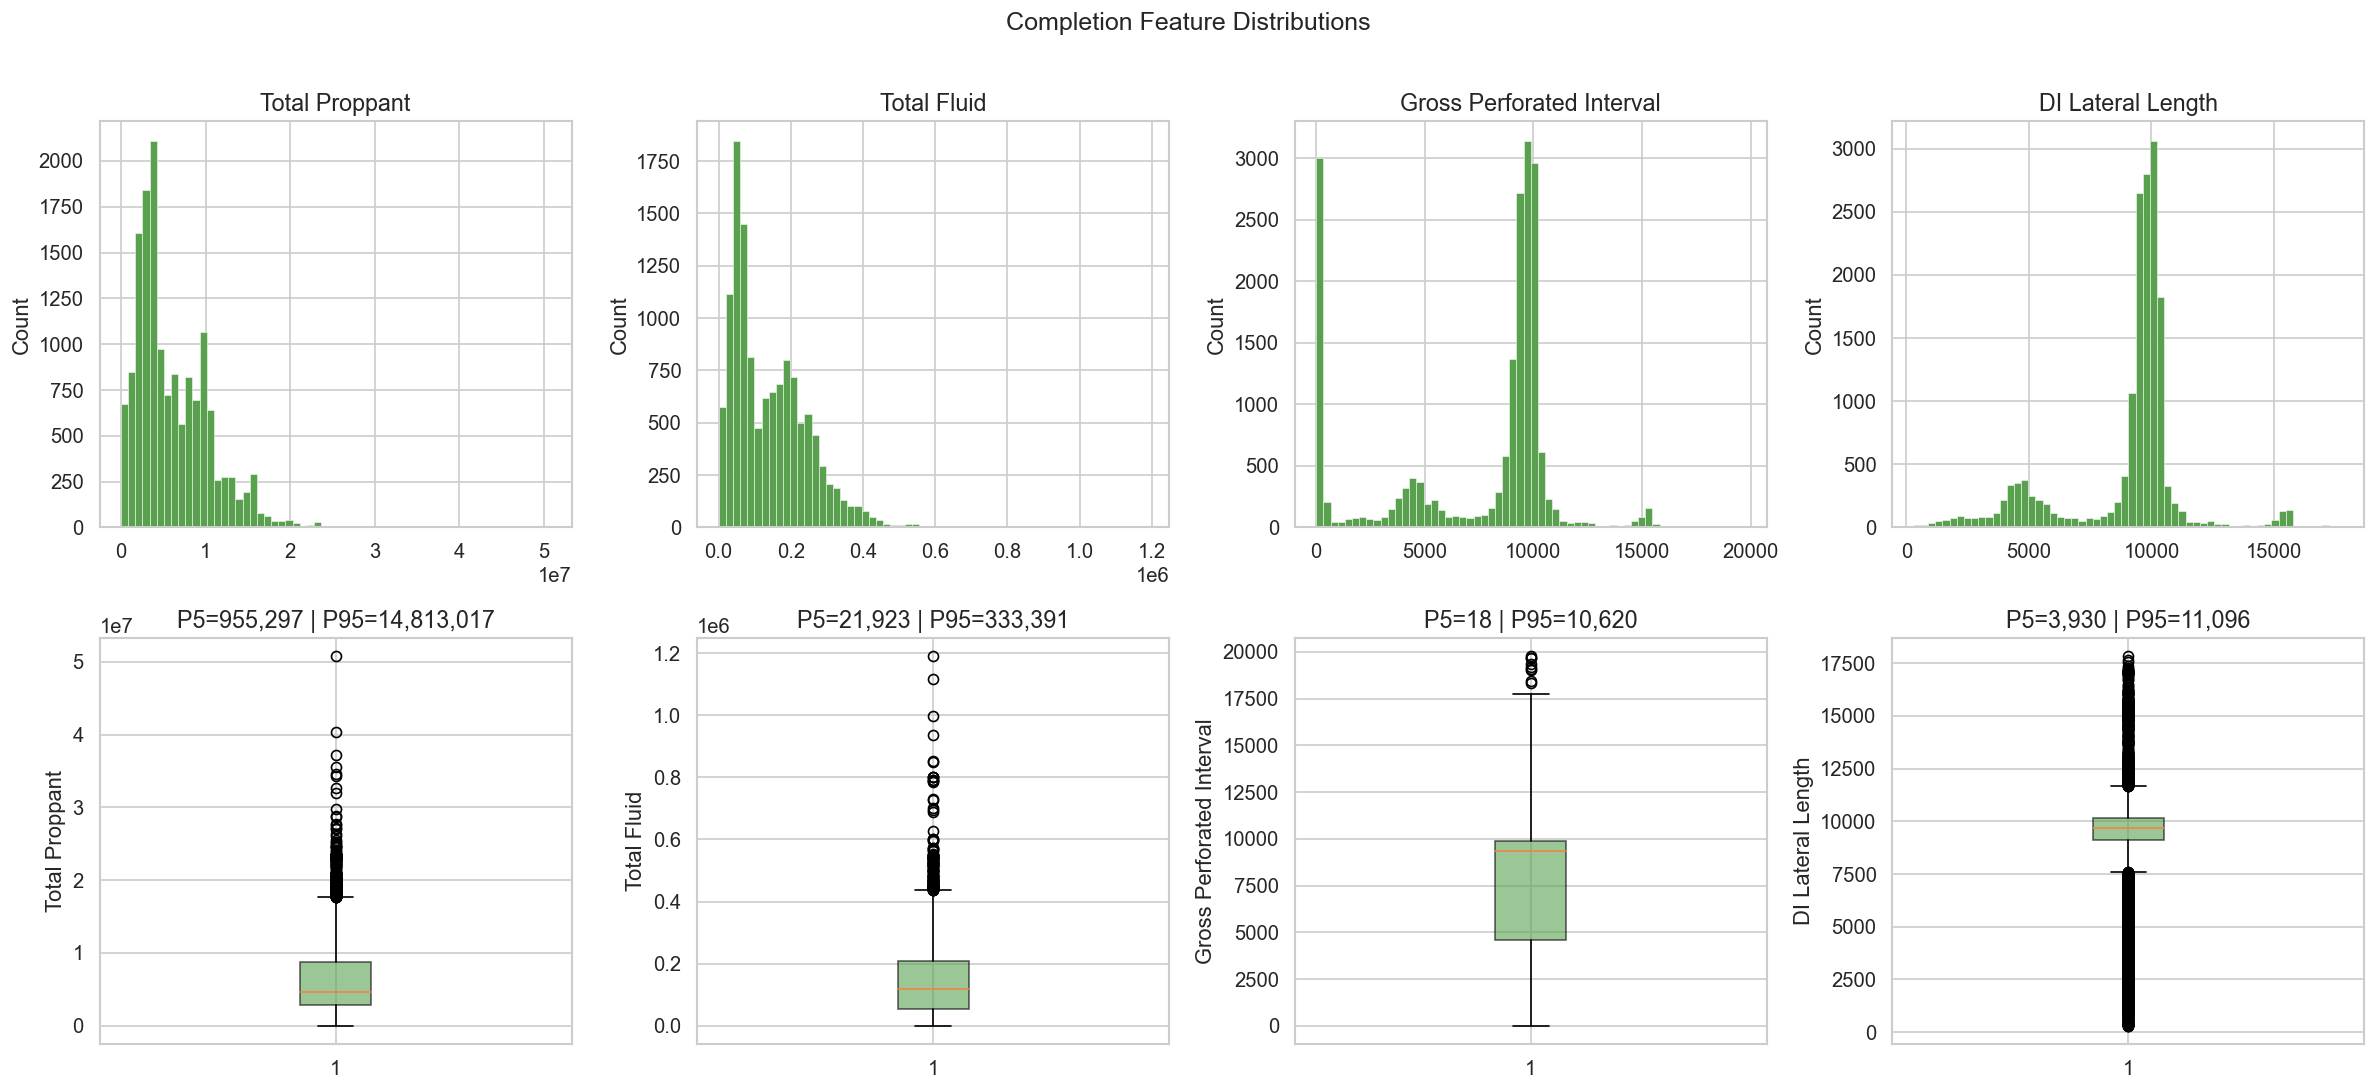

In [176]:
#  Numeric feature distributions 
num_features = [
    "Total Proppant",
    "Total Fluid",
    "Gross Perforated Interval",
    "DI Lateral Length"
]

available = [
    f for f in num_features
    if f in df_eda.columns and df_eda[f].notna().sum() > 0
]

if len(available) == 0:
    print("No numeric completion features available with non-missing values.")
    print("Check column names and missing values:")
    display(df_eda[num_features].isna().sum() if all(f in df_eda.columns for f in num_features) else df_eda.columns)
else:
    fig, axes = plt.subplots(
        2,
        len(available),
        figsize=(5 * len(available), 9),
        squeeze=False
    )

    for i, feat in enumerate(available):
        vals = pd.to_numeric(df_eda[feat], errors="coerce").dropna()

        # Histogram
        axes[0, i].hist(
            vals,
            bins=60,
            color="#59a14f",
            edgecolor="white",
            linewidth=0.3
        )
        axes[0, i].set_title(feat)
        axes[0, i].set_ylabel("Count")

        # Boxplot
        axes[1, i].boxplot(
            vals,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor="#59a14f", alpha=0.6)
        )
        axes[1, i].set_ylabel(feat)

        p5, p95 = vals.quantile(0.05), vals.quantile(0.95)
        axes[1, i].set_title(f"P5={p5:,.0f} | P95={p95:,.0f}")

    plt.suptitle("Completion Feature Distributions", y=1.01, fontsize=15)
    plt.tight_layout()
    plt.show()

The completion-related variables exhibit substantial variability, skewness, and distinct operational patterns, indicating that completion design differs significantly across wells. The distributions are physically reasonable and consistent with unconventional reservoir development practices. Although several features contain statistical outliers, these observations likely represent legitimate engineering decisions rather than data errors and will therefore be retained. Collectively, proppant volume, fluid volume, perforated interval, and lateral length are expected to be among the most influential predictors of first-year cumulative oil production and will be included in subsequent machine learning models.

## 5. Correlation Analysis

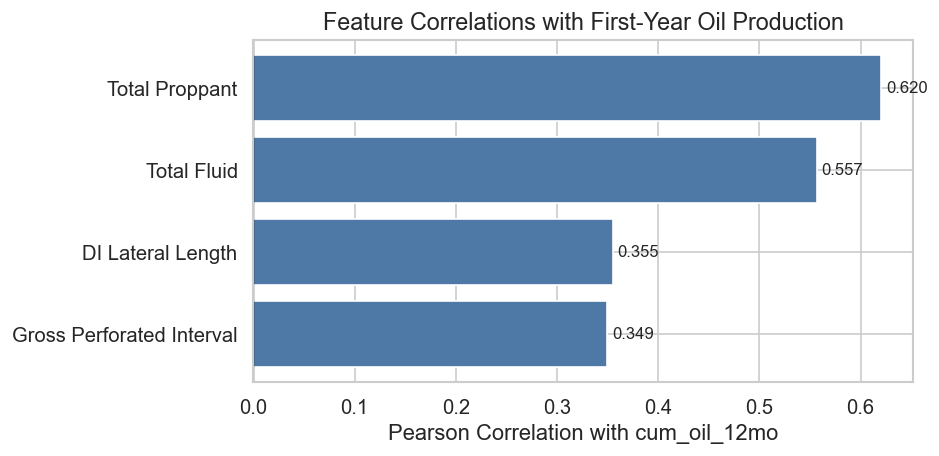

In [177]:
# Pearson correlations with target
num_cols = [c for c in ["Total Proppant", "Total Fluid", "Gross Perforated Interval",
                         "DI Lateral Length"] if c in df_eda.columns]

corr_df = df_eda[num_cols + ["cum_oil_12mo"]].dropna()
corr = corr_df.corr()["cum_oil_12mo"].drop("cum_oil_12mo").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4e79a7" if v >= 0 else "#e15759" for v in corr]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.set_xlabel("Pearson Correlation with cum_oil_12mo")
ax.set_title("Feature Correlations with First-Year Oil Production")
ax.axvline(0, color="black", linewidth=0.8)
for i, (val, name) in enumerate(zip(corr.values[::-1], corr.index[::-1])):
    ax.text(val + 0.005 if val >= 0 else val - 0.005, i,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=10)
plt.tight_layout()
plt.show()


Pearson correlation analysis was performed to evaluate the relationship between completion design variables and first-year cumulative oil production. All completion-related features exhibited positive correlations with the target variable, indicating that larger completions tend to be associated with higher production. Lateral length and proppant volume demonstrated the strongest relationships, suggesting that reservoir exposure and stimulation intensity are major drivers of early well performance. While no single feature fully explains production variability, the results confirm that completion design variables contain meaningful predictive information and should be retained for machine learning modeling.

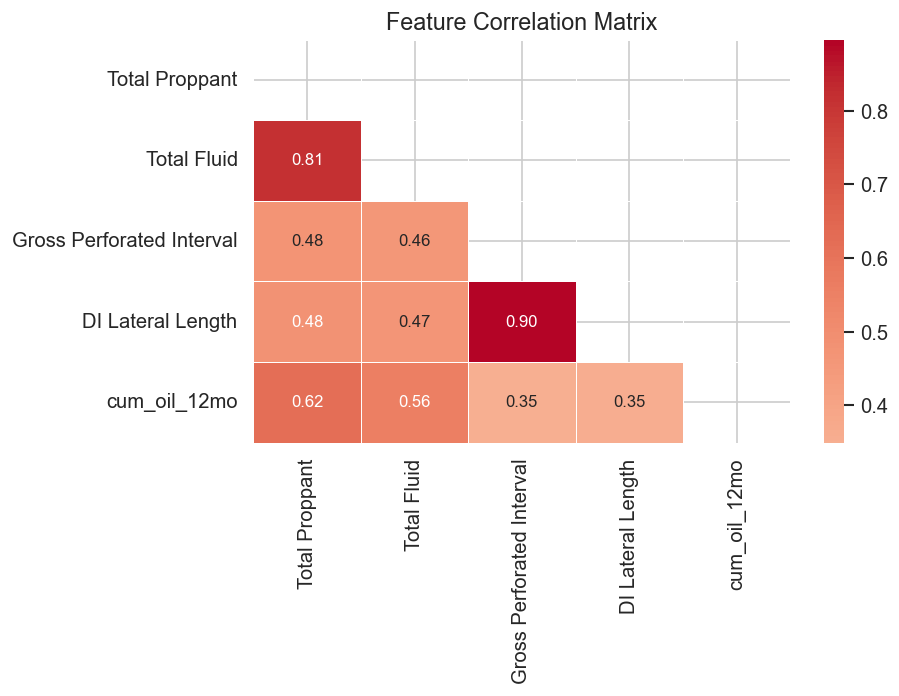


 Highly correlated features (>0.85) may cause multicollinearity in linear models.


In [178]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, annot_kws={"size": 10}
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()
print("\n Highly correlated features (>0.85) may cause multicollinearity in linear models.")


Correlation analysis revealed strong relationships among completion design variables. DI Lateral Length and Gross Perforated Interval exhibited a very strong positive correlation (r = 0.90), indicating that both variables describe similar aspects of reservoir exposure. Total Proppant and Total Fluid were also highly correlated (r = 0.81), reflecting the tendency for larger hydraulic fracture treatments to require greater fluid volumes. Despite these interrelationships, Total Proppant (r = 0.62) and Total Fluid (r = 0.56) demonstrated the strongest correlations with first-year cumulative oil production, suggesting that completion intensity is a major driver of well performance. Because tree-based machine learning algorithms are robust to multicollinearity, all completion variables will be retained for subsequent modeling and feature importance analysis.

## 6. Production Decline Curves

Decline curves are fundamental to petroleum engineering. We'll visualize average production by month to understand the hyperbolic decline pattern.

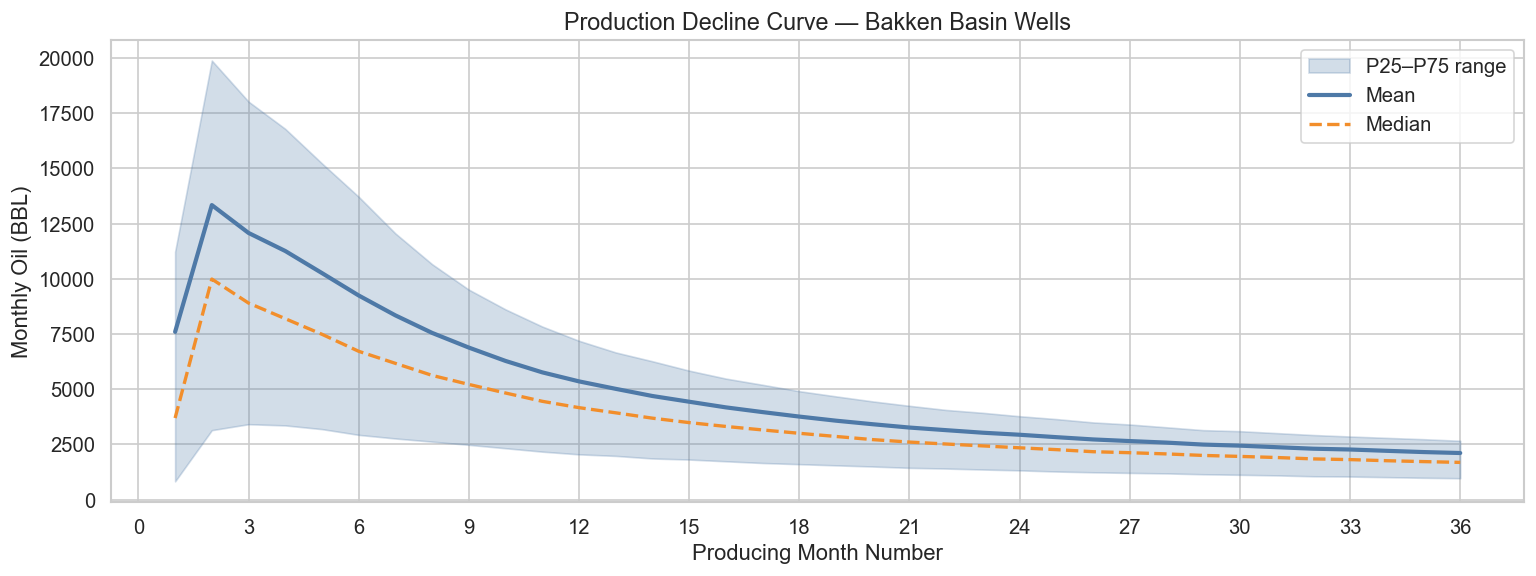

 Rapid hyperbolic decline in months 1-6 is typical of tight-oil shale wells.
   This confirms decline_rate_m1_to_m6 is an informative engineered feature.


In [179]:
#  Average monthly oil by producing month 
decline = (
    df_oil[df_oil["Producing Month Number"].between(1, 36)]
    .groupby("Producing Month Number")["Monthly Oil"]
    .agg(["mean", "median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    .reset_index()
)
decline.columns = ["month", "mean", "median", "p25", "p75"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(decline["month"], decline["p25"], decline["p75"],
                alpha=0.25, color="#4e79a7", label="P25–P75 range")
ax.plot(decline["month"], decline["mean"],   color="#4e79a7", linewidth=2.5, label="Mean")
ax.plot(decline["month"], decline["median"], color="#f28e2b", linewidth=2,
        linestyle="--", label="Median")
ax.set_xlabel("Producing Month Number")
ax.set_ylabel("Monthly Oil (BBL)")
ax.set_title("Production Decline Curve — Bakken Basin Wells")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
plt.tight_layout()
plt.show()
print(" Rapid hyperbolic decline in months 1-6 is typical of tight-oil shale wells.")
print("   This confirms decline_rate_m1_to_m6 is an informative engineered feature.")

The production decline curve exhibits the characteristic behavior of unconventional shale wells, with production increasing rapidly during the first two months before entering a sustained decline phase. Average monthly oil production peaks at approximately 13,300 BBL/month during the second producing month, while the median reaches approximately 10,000 BBL/month, indicating that many wells achieve their maximum production shortly after coming online. Following the peak, production declines steadily, with average monthly oil production decreasing to approximately 5,300 BBL/month by month 12 and 2,100 BBL/month by month 36. This represents an approximate 84% decline from peak production over the first three years.

The shaded P25–P75 interval demonstrates substantial variability in well performance, particularly during the early production period. The spread between high- and low-performing wells is greatest during the first year, reflecting differences in reservoir quality, completion design, landing zone selection, and operational practices. As wells mature, the production distributions gradually converge, although significant variability remains throughout the life of the wells.

The consistent separation between the mean and median production curves indicates a positively skewed production distribution, where a relatively small number of exceptionally productive wells elevate the average production above the typical well performance. This observation is consistent with the earlier analysis of first-year cumulative oil production and further supports the use of logarithmic transformations for machine learning modeling.

Overall, the decline curve confirms that Producing Month Number is a critical predictor of production performance. Well age captures the dominant decline behavior inherent in unconventional reservoirs and is therefore expected to be one of the most influential features in the machine learning models developed in this study.

## 7. Geological & Geographic Patterns

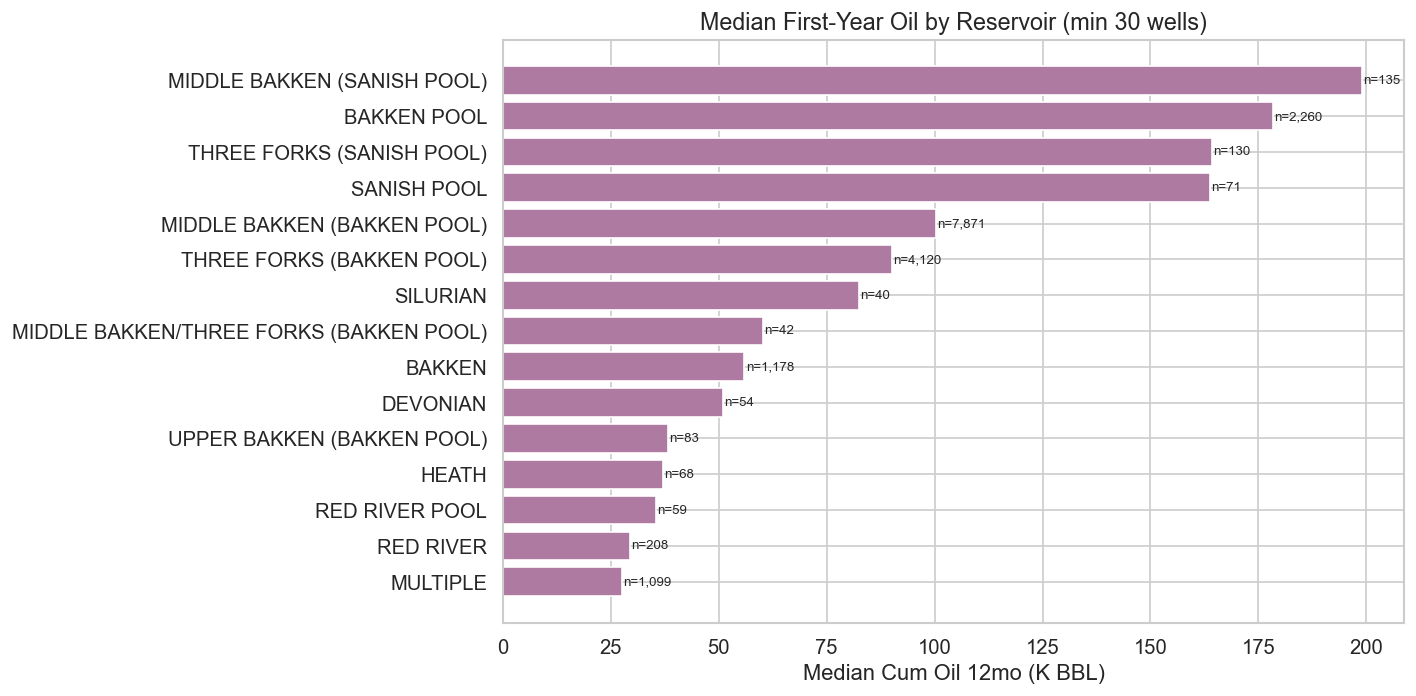

In [180]:
#  Production by Reservoir
if "Reservoir" in df_eda.columns:
    res_stats = (
        df_eda.groupby("Reservoir")["cum_oil_12mo"]
        .agg(["median", "count"])
        .query("count >= 30")
        .sort_values("median", ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(res_stats.index[::-1], res_stats["median"][::-1] / 1e3, color="#af7aa1")
    ax.set_xlabel("Median Cum Oil 12mo (K BBL)")
    ax.set_title("Median First-Year Oil by Reservoir (min 30 wells)")
    for bar, cnt in zip(bars, res_stats["count"][::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"n={cnt:,}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


The reservoir ranking shows substantial differences in first-year oil recovery across formations. The highest-performing reservoirs are Middle Bakken (Sanish Pool), Bakken Pool, Three Forks (Sanish Pool), and Sanish Pool, all exhibiting median first-year oil production exceeding approximately 160–200 thousand barrels. In contrast, reservoirs such as Multiple, Red River, and Heath display considerably lower median production levels. The large production gap between reservoir types confirms that geological characteristics play a major role in determining well productivity. These results support retaining Reservoir as a key predictive feature in the machine learning model and suggest that formation selection is one of the most important drivers of economic performance in the Bakken Basin.

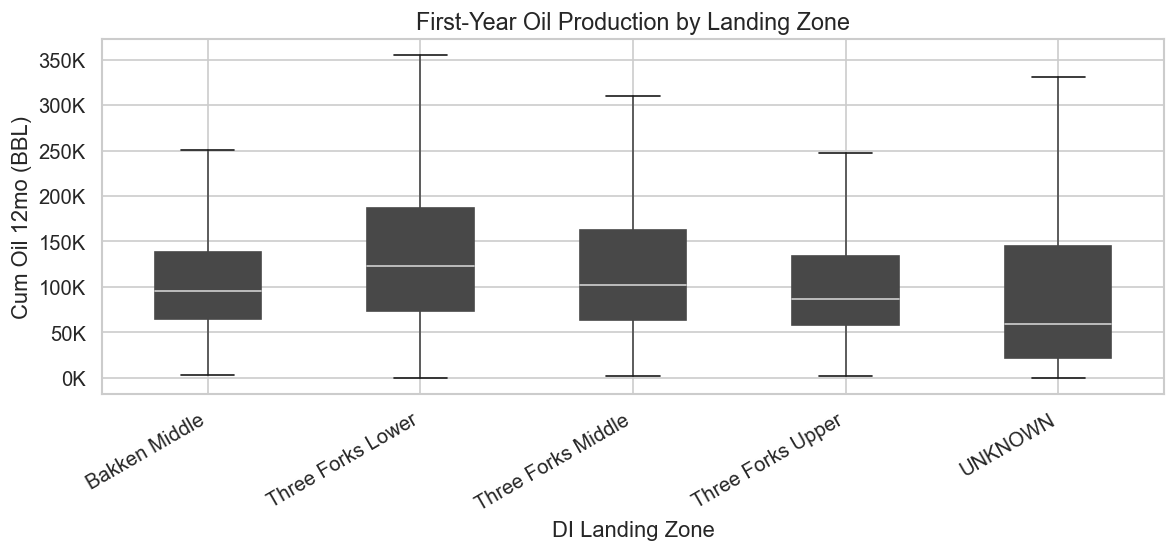

In [181]:
# Production by DI Landing Zone
if "DI Landing Zone" in df_eda.columns:
    lz_counts = df_eda["DI Landing Zone"].value_counts()
    lz_valid = lz_counts[lz_counts >= 20].index
    lz_df = df_eda[df_eda["DI Landing Zone"].isin(lz_valid)]

    fig, ax = plt.subplots(figsize=(10, 5))
    lz_df.boxplot(column="cum_oil_12mo", by="DI Landing Zone", ax=ax,
                  patch_artist=True, showfliers=False)
    ax.set_ylabel("Cum Oil 12mo (BBL)")
    ax.set_title("First-Year Oil Production by Landing Zone")
    plt.suptitle("")
    plt.xticks(rotation=30, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    plt.tight_layout()
    plt.show()



Wells completed in the Three Forks Lower interval exhibit the highest median first-year oil production, followed by Three Forks Middle and Bakken Middle wells. The Three Forks Upper interval shows somewhat lower production performance, while wells with unknown landing zones exhibit the greatest variability. These results indicate that vertical placement within the reservoir significantly impacts well productivity, likely due to differences in rock quality, hydrocarbon saturation, natural fracturing, and reservoir pressure. 

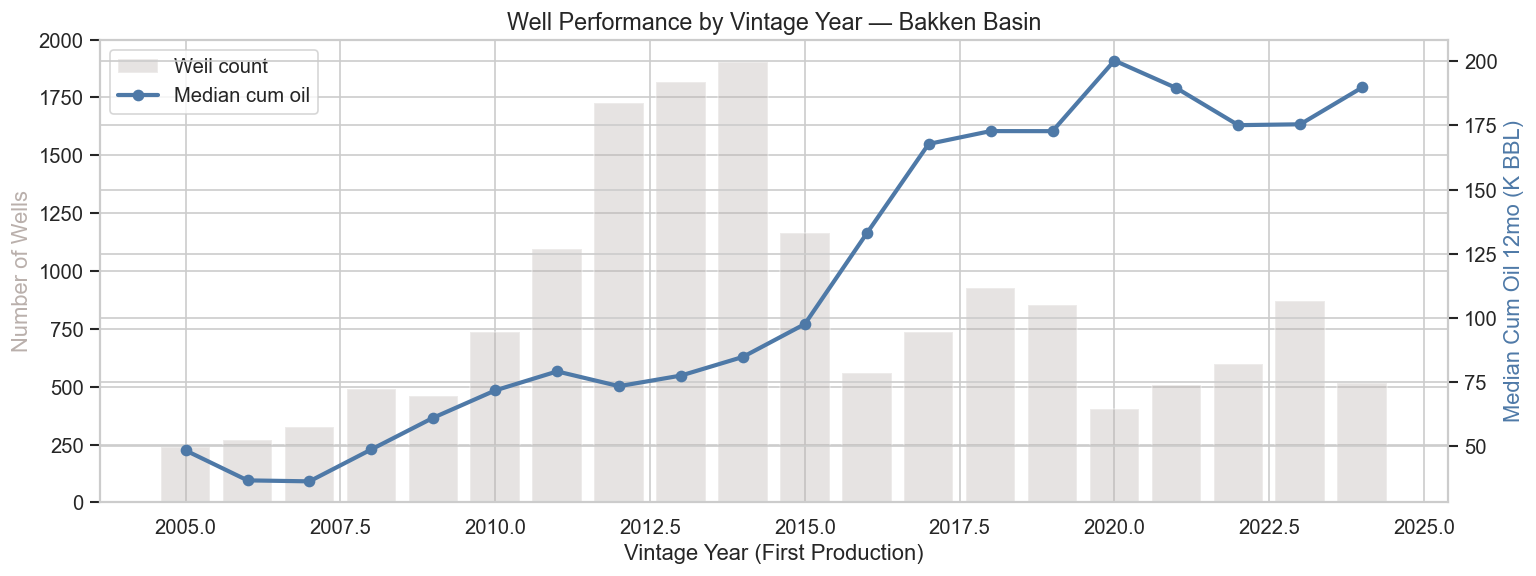

 Vintage year captures technology improvements and will be consider adding as a feature.


In [182]:
# Production trend over vintage year 
df_oil["Year"] = df_oil["Monthly Production Date"].dt.year
first_year = df_oil[df_oil["Producing Month Number"] == 1][["API/UWI", "Year"]].drop_duplicates()
vintage = target.merge(first_year, on="API/UWI", how="left")

vintage_stats = (
    vintage[vintage["Year"].between(2005, 2024)]
    .groupby("Year")["cum_oil_12mo"]
    .agg(["median", "count"])
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
ax1.bar(vintage_stats["Year"], vintage_stats["count"], alpha=0.35, color="#bab0ac", label="Well count")
ax2.plot(vintage_stats["Year"], vintage_stats["median"] / 1e3, "o-",
         color="#4e79a7", linewidth=2.5, label="Median cum oil")
ax1.set_xlabel("Vintage Year (First Production)")
ax1.set_ylabel("Number of Wells", color="#bab0ac")
ax2.set_ylabel("Median Cum Oil 12mo (K BBL)", color="#4e79a7")
ax1.set_title("Well Performance by Vintage Year — Bakken Basin")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()
print(" Vintage year captures technology improvements and will be consider adding as a feature.")


The vintage analysis shows a clear improvement in well performance over time. Median first-year cumulative oil production increased steadily from approximately 40–80 thousand barrels for wells drilled between 2005 and 2013 to approximately 160–200 thousand barrels for wells drilled after 2017. The most productive vintages occur between 2020 and 2024, where median first-year production approaches or exceeds 180 thousand barrels. This improvement coincides with advances in horizontal drilling and completion technology, including longer laterals, higher proppant loading, increased fluid volumes, improved landing zone targeting, and enhanced completion designs. The trend suggests that vintage year captures technological evolution and operational learning and therefore represents an important feature for production forecasting models.

The accompanying well-count bars show that drilling activity increased substantially between 2011 and 2015 before moderating in later years. Despite fewer wells being drilled in recent years, median production performance continued to improve, indicating that gains in well quality have more than offset reductions in drilling volume.

### Summary
Taken together, these analyses suggest that first-year oil production is controlled by three major factors:

- Geology: represented by Reservoir and Landing Zone.
- Completion Design: represented by Proppant, Fluid, Lateral Length, and Perforated Interval.
- Technology Evolution: represented by Vintage Year.

The vintage trend is particularly important because it indicates that production improvements are not solely due to reservoir quality but also reflect advancements in drilling and completion practices over time. Consequently, Reservoir, DI Landing Zone, Vintage Year, Total Proppant, Total Fluid, DI Lateral Length, and Gross Perforated Interval should all be retained as core features for machine learning model development. These variables collectively capture the geological, operational, and technological drivers of well performance in the Bakken Basin.

## 8. Completion Design Analysis

How do frac design parameters affect first-year production?

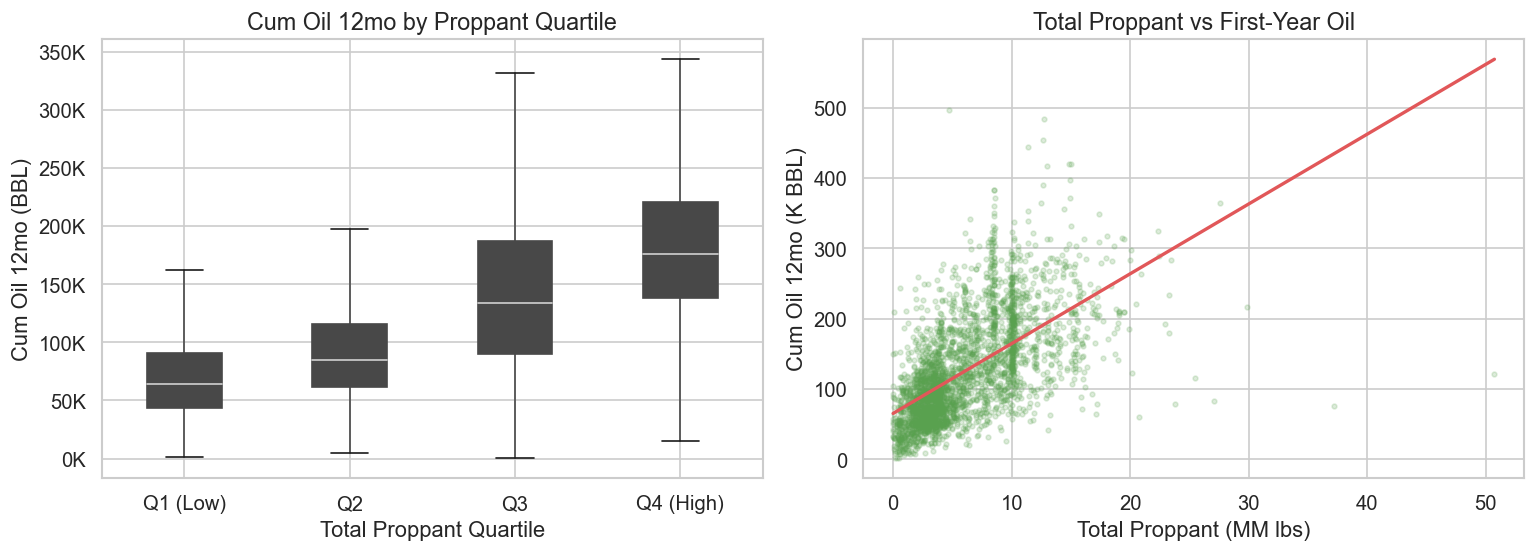

In [183]:
# ── Proppant loading vs production (quartile bins) ──
if "Total Proppant" in df_eda.columns:
    sub = df_eda[["Total Proppant", "cum_oil_12mo"]].dropna()
    sub["proppant_bin"] = pd.qcut(sub["Total Proppant"], q=4,
                                   labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Box plot by proppant quartile
    sub.boxplot(column="cum_oil_12mo", by="proppant_bin", ax=axes[0],
                patch_artist=True, showfliers=False)
    axes[0].set_title("Cum Oil 12mo by Proppant Quartile")
    axes[0].set_xlabel("Total Proppant Quartile")
    axes[0].set_ylabel("Cum Oil 12mo (BBL)")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    plt.sca(axes[0]); plt.title("Cum Oil 12mo by Proppant Quartile")

    # Scatter with trend
    sample = sub.sample(min(3000, len(sub)), random_state=42)
    axes[1].scatter(sample["Total Proppant"] / 1e6, sample["cum_oil_12mo"] / 1e3,
                    alpha=0.2, s=8, color="#59a14f")
    z = np.polyfit(sample["Total Proppant"], sample["cum_oil_12mo"], 1)
    x_line = np.linspace(sample["Total Proppant"].min(), sample["Total Proppant"].max(), 100)
    axes[1].plot(x_line / 1e6, np.polyval(z, x_line) / 1e3, color="#e15759", linewidth=2)
    axes[1].set_xlabel("Total Proppant (MM lbs)")
    axes[1].set_ylabel("Cum Oil 12mo (K BBL)")
    axes[1].set_title("Total Proppant vs First-Year Oil")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()


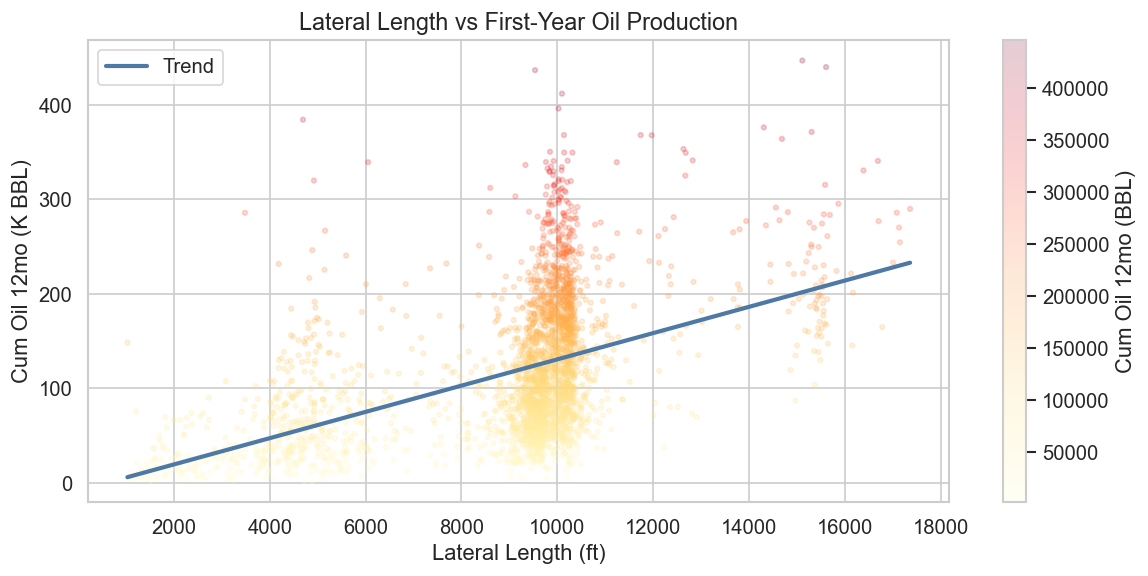

Pearson r = 0.473, p-value = 4.49e-167


In [184]:
# Lateral length vs production
if "DI Lateral Length" in df_eda.columns:
    sub = df_eda[["DI Lateral Length", "cum_oil_12mo"]].dropna()
    sub = sub[sub["DI Lateral Length"].between(1000, 25000)]  # filter extreme outliers

    fig, ax = plt.subplots(figsize=(10, 5))
    sample = sub.sample(min(3000, len(sub)), random_state=42)
    sc = ax.scatter(sample["DI Lateral Length"], sample["cum_oil_12mo"] / 1e3,
                    alpha=0.2, s=8, c=sample["cum_oil_12mo"], cmap="YlOrRd")
    z = np.polyfit(sample["DI Lateral Length"], sample["cum_oil_12mo"], 1)
    x_line = np.linspace(sample["DI Lateral Length"].min(), sample["DI Lateral Length"].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line) / 1e3, color="#4e79a7", linewidth=2.5, label="Trend")
    plt.colorbar(sc, label="Cum Oil 12mo (BBL)")
    ax.set_xlabel("Lateral Length (ft)")
    ax.set_ylabel("Cum Oil 12mo (K BBL)")
    ax.set_title("Lateral Length vs First-Year Oil Production")
    ax.legend()
    plt.tight_layout()
    plt.show()
    r, p = stats.pearsonr(sample["DI Lateral Length"], sample["cum_oil_12mo"])
    print(f"Pearson r = {r:.3f}, p-value = {p:.2e}")


Fracture design parameters exhibit a strong influence on first-year oil production. Wells in the highest proppant quartile achieve median first-year oil production approximately three times greater than wells in the lowest quartile, indicating a substantial production uplift associated with larger fracture treatments. Scatter plot analysis further demonstrates a clear positive relationship between total proppant volume and cumulative oil production, consistent with the strong Pearson correlation observed earlier (r = 0.62). Lateral length also shows a positive relationship with production, although its influence is weaker than that of proppant volume. Overall, the results suggest that completion intensity, represented by proppant and fluid volumes, is a more important driver of early well performance than well geometry alone. These findings highlight the critical role of fracture design in maximizing recovery from Bakken Basin wells and justify the inclusion of completion variables as key predictors in subsequent machine learning models.

# 9. Key Findings & Modeling Implications

## Target Variable

The target variable, **First-Year Cumulative Oil Production (`cum_oil_12mo`)**, was calculated by summing monthly oil production over the first 12 producing months for wells with complete production histories. A total of **20,601 wells** met this criterion.

Key observations include:

- Strong positive skewness with a long upper tail.
- A small number of exceptionally productive wells drive the upper end of the distribution.
- Log transformation (`log1p`) substantially reduces skewness and improves normality.
- High-producing wells represent valid field performance and were retained.

**Modeling Decision:** Train models on `log(cum_oil_12mo)` and back-transform predictions using `expm1()`.

---

## Data Quality Findings

### Duplicate Records
- No duplicate records were identified.

### Invalid Production Data
- Negative oil, gas, and water production values represented less than 0.01% of observations.
- These records were removed because production volumes cannot be physically negative.

### Producing Days Validation
- Records with missing or non-positive producing days were removed.
- Approximately **1.31%** of observations were excluded.
- More than **4.1 million production records** were retained for analysis.

### Missing Values

| Feature | Missing (%) |
|----------|------------:|
| DI Landing Zone | ~62% |
| Total Fluid | ~63% |
| Total Proppant | ~49% |
| DI Lateral Length | ~41% |
| Gross Perforated Interval | ~13% |

Missing numerical values will be imputed using the median, while missing categorical values will be assigned an `"UNKNOWN"` category.

---

## Geological Drivers of Production

### Reservoir Performance

Reservoir type exhibits substantial differences in first-year production performance.

Highest-performing reservoirs include:

- Middle Bakken (Sanish Pool)
- Bakken Pool
- Three Forks (Sanish Pool)
- Sanish Pool

Lower-performing reservoirs include:

- Multiple
- Red River
- Heath

These results confirm that reservoir quality is a major driver of well productivity.

### Landing Zone Performance

Production performance varies significantly across landing zones.

- Three Forks Lower exhibits the highest median first-year oil production.
- Three Forks Middle and Bakken Middle also perform strongly.
- Wells with unknown landing zones show greater variability.

Despite substantial missingness, DI Landing Zone contains valuable predictive information and should be retained.

---

## Production Lifecycle Behavior

The decline curve analysis demonstrates typical unconventional shale-well behavior.

Key observations:

- Peak production occurs within the first few months.
- Average production declines by approximately 80–85% over the first three years.
- Significant variability exists between wells, particularly during early production.

The persistent decline trend confirms that **Producing Month Number** is a critical predictive feature.

---

## Technology Evolution

Well performance has improved substantially over time.

Median first-year cumulative oil production increased from approximately:

- **40–80 MBbl** for early wells (2005–2010)
- **160–200 MBbl** for recent wells (2018–2024)

This improvement reflects advancements in:

- Longer laterals
- Larger fracture treatments
- Improved landing zone targeting
- Better completion design

**Vintage Year** should therefore be included as a feature to capture technological progress.

---

## Completion Design Effects

Completion intensity exhibits the strongest relationship with first-year production.

### Correlation with First-Year Oil Production

| Feature | Correlation |
|----------|------------:|
| Total Proppant | 0.620 |
| Total Fluid | 0.557 |
| DI Lateral Length | 0.355 |
| Gross Perforated Interval | 0.349 |

### Key Findings

- Wells in the highest proppant quartile produce approximately **three times more oil** than wells in the lowest quartile.
- Higher proppant and fluid volumes consistently result in higher production.
- Longer laterals and perforated intervals improve performance but are less influential than completion intensity.

**Conclusion:** Completion intensity is a stronger driver of first-year production than well geometry alone.

---

## Multicollinearity Assessment

Strong correlations exist among completion variables:

| Feature Pair | Correlation |
|--------------|------------:|
| DI Lateral Length ↔ Gross Perforated Interval | 0.90 |
| Total Proppant ↔ Total Fluid | 0.81 |

These relationships are physically meaningful and reflect modern completion practices.

For tree-based models, all variables will be retained.

---

## Most Important Features

Based on correlation analysis, production trends, and engineering interpretation, the most influential predictors are:

### Completion Features
- Total Proppant
- Total Fluid
- DI Lateral Length
- Gross Perforated Interval

### Geological Features
- Reservoir
- DI Landing Zone

### Operational Features
- Producing Month Number
- Well Status
- Production Type

### Temporal Features
- Vintage Year

### Business Features
- Operator Company Name

---

## Modeling Recommendations

### Target Transformation

```python
y = np.log1p(cum_oil_12mo)
```

Predictions:

```python
pred_bbl = np.expm1(pred_log)
```

### Feature Encoding

- Numerical Features → Median imputation + scaling if required
- Categorical Features → `"UNKNOWN"` imputation
- Tree-based models can use target/frequency encoding or CatBoost encoding

### Candidate Models

1. Random Forest Regressor
2. XGBoost Regressor
3. LightGBM Regressor
4. CatBoost Regressor

Expected best performer:

**XGBoost or LightGBM**

### Train-Test Strategy

Use a **well-level split** to prevent data leakage.

Recommended:

- Train: 80%
- Test: 20%

Stratify by:

- Reservoir

---

## Overall Conclusion

The analysis demonstrates that first-year oil production in the Bakken Basin is primarily controlled by three factors:

1. **Geology** (Reservoir and Landing Zone)
2. **Completion Design** (Proppant, Fluid, Lateral Length, Perforated Interval)
3. **Technology Evolution** (Vintage Year)

Among all evaluated variables, **Total Proppant emerged as the strongest individual predictor of first-year cumulative oil production**, while reservoir and landing-zone analyses confirmed the importance of geological placement. The combination of geological, completion, operational, and temporal features provides a strong foundation for developing robust machine learning models capable of accurately forecasting first-year oil production.


In [185]:
# Save a quick summary stats table
summary = df_eda[["cum_oil_12mo", "Total Proppant", "Total Fluid",
                   "Gross Perforated Interval", "DI Lateral Length"]].describe().T
summary.columns = ["count","mean","std","min","25%","50%","75%","max"]
print("=== Feature Summary Statistics ===")
print(summary.applymap(lambda x: f"{x:,.1f}").to_string())


=== Feature Summary Statistics ===
                              count         mean          std    min          25%          50%          75%           max
cum_oil_12mo               20,601.0    100,247.2     75,296.9    0.0     41,548.0     83,002.0    144,892.0     533,656.0
Total Proppant             15,212.0  6,084,256.7  4,344,586.1   13.0  2,834,567.8  4,635,349.0  8,768,887.2  50,743,510.0
Total Fluid                12,525.0    141,455.5    105,870.4    5.0     55,404.0    118,392.0    207,705.0   1,189,168.3
Gross Perforated Interval  19,171.0      7,359.7      3,955.4    1.0      4,569.5      9,357.0      9,862.0      19,758.0
DI Lateral Length          16,812.0      8,984.2      2,504.8  303.1      9,117.0      9,700.0     10,144.0      17,817.0
